# 🌸 PureGlow AI — Exploratory Data Analysis
**Notebook:** `02_data_analysis.ipynb`

Understand the cleaned datasets before building the recommendation engine.

**Sections:**
1. Setup & Load Cleaned Data
2. Reviews Analysis
3. Skincare Products Analysis
4. Makeup Analysis
5. Popularity & Rankings
6. Ingredients Analysis
7. Key Insights Summary

In [1]:
# ── Core Imports ─────────────────────────────────────────────────────────────
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#fdf6f0',
    'axes.facecolor': '#fdf6f0',
    'axes.edgecolor': '#e8d5c4',
    'axes.labelcolor': '#5a3e36',
    'xtick.color': '#5a3e36',
    'ytick.color': '#5a3e36',
    'text.color': '#5a3e36',
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

PALETTE = ['#c9808a', '#e8a598', '#f2c4a0', '#d4a5c9', '#8fbcbb',
           '#a8c5a0', '#f0d080', '#b5a4d4', '#e07b8a', '#7ab8c2']

# ── Paths ─────────────────────────────────────────────────────────────────────
CLEAN_DIR = Path('../data/cleaned').resolve()
REPORTS_DIR = Path('../reports').resolve()
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Cleaned data : {CLEAN_DIR}')
print(f'Reports      : {REPORTS_DIR}')

# ── Helper ────────────────────────────────────────────────────────────────────
def load(filename):
    path = CLEAN_DIR / filename
    if not path.exists():
        print(f'  ⚠  Not found: {filename}')
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f'  ✓ {filename:<45} {df.shape[0]:>8,} rows × {df.shape[1]:>3} cols')
    return df

def savefig(name):
    path = REPORTS_DIR / f'{name}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=plt.rcParams['figure.facecolor'])
    print(f'  📊 Saved → {path.name}')

def section(title):
    print('\n' + '═'*70)
    print(f'  {title}')
    print('═'*70)

print('\n✅ Setup complete!')

Cleaned data : C:\Users\HP\OneDrive\Desktop\PureGlow AI\data\cleaned
Reports      : C:\Users\HP\OneDrive\Desktop\PureGlow AI\reports

✅ Setup complete!


In [2]:
# ── Load All Cleaned Datasets ─────────────────────────────────────────────────
print('Loading all cleaned datasets...\n')

reviews        = load('01_reviews_clean.csv')
skincare       = load('02_skincare_products_clean.csv')
urls           = load('03_product_urls_clean.csv')
rankings       = load('04_popularity_rankings_clean.csv')
product_info   = load('05_product_info_clean.csv')
productlist    = load('06_productlist_clean.csv')
sephora        = load('07_sephora_clean.csv')
brands         = load('08_brands_clean.csv')
makeup         = load('09_makeup_clean.csv')
ingredients    = load('10_ingredients_clean.csv')
paula_sum      = load('11_paula_sumlist_clean.csv')
alternatives   = load('13_alternatives_clean.csv')
output         = load('15_output_clean.csv')
pretty_nums    = load('16_pretty_numbers_clean.csv')

datasets = {
    'Reviews': reviews, 'Skincare': skincare, 'URLs': urls,
    'Rankings': rankings, 'Product Info': product_info,
    'Product List': productlist, 'Sephora': sephora, 'Brands': brands,
    'Makeup': makeup, 'Ingredients': ingredients,
}

print(f'\n📦 Total datasets loaded: {sum(1 for df in datasets.values() if not df.empty)}')
print(f'📝 Total rows across all: {sum(len(df) for df in datasets.values() if not df.empty):,}')

Loading all cleaned datasets...

  ✓ 01_reviews_clean.csv                          1,094,411 rows ×  19 cols
  ✓ 02_skincare_products_clean.csv                   3,474 rows ×  49 cols
  ✓ 03_product_urls_clean.csv                            4 rows ×   6 cols
  ✓ 04_popularity_rankings_clean.csv                   400 rows ×   8 cols
  ✓ 05_product_info_clean.csv                        8,494 rows ×  27 cols
  ✓ 06_productlist_clean.csv                           237 rows ×   7 cols
  ✓ 07_sephora_clean.csv                             2,179 rows ×  20 cols
  ✓ 08_brands_clean.csv                                100 rows ×   3 cols
  ✓ 09_makeup_clean.csv                                931 rows ×  19 cols
  ✓ 10_ingredients_clean.csv                        66,417 rows ×   2 cols
  ✓ 11_paula_sumlist_clean.csv                      26,087 rows ×   4 cols
  ✓ 13_alternatives_clean.csv                        1,334 rows ×   2 cols
  ✓ 15_output_clean.csv                                931 rows × 

---
## 1. Dataset Overview


══════════════════════════════════════════════════════════════════════
  DATASET OVERVIEW
══════════════════════════════════════════════════════════════════════


,Rows,Columns,Missing %,Duplicates
Dataset,,,,
Reviews,1094411,19,9.40,0
Skincare,3474,49,43.30,0
URLs,4,6,50.00,0
Rankings,400,8,46.90,0
Product Info,8494,27,19.30,0
Product List,237,7,0.00,0
Sephora,2179,20,26.50,0
Brands,100,3,0.00,0
Makeup,931,19,25.00,0


  📊 Saved → 00_dataset_overview.png


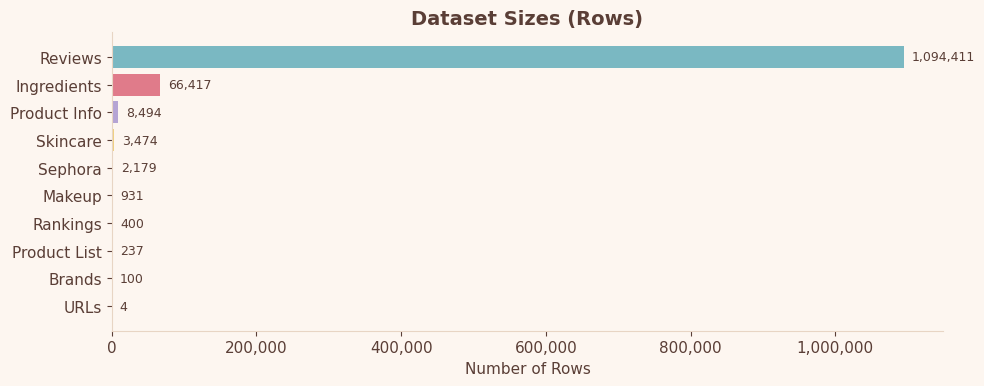

In [3]:
section('DATASET OVERVIEW')

overview = []
for name, df in datasets.items():
    if not df.empty:
        missing_pct = df.isnull().mean().mean() * 100
        dups = df.duplicated().sum()
        overview.append({
            'Dataset': name,
            'Rows': len(df),
            'Columns': len(df.columns),
            'Missing %': round(missing_pct, 1),
            'Duplicates': dups
        })

overview_df = pd.DataFrame(overview).set_index('Dataset')
display(overview_df)

# Bar chart of dataset sizes
fig, ax = plt.subplots(figsize=(10, 4))
sizes = overview_df['Rows'].sort_values(ascending=True)
bars = ax.barh(sizes.index, sizes.values, color=PALETTE[:len(sizes)])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_title('Dataset Sizes (Rows)')
ax.set_xlabel('Number of Rows')
for bar, val in zip(bars, sizes.values):
    ax.text(val + sizes.max()*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
savefig('00_dataset_overview')
plt.show()

---
## 2. Reviews Analysis

In [4]:
section('REVIEWS ANALYSIS')

if reviews.empty:
    print('⚠️  Reviews data not available')
else:
    print(f'Shape: {reviews.shape}')
    print(f'\nColumns: {list(reviews.columns)}')
    print(f'\nData types:')
    display(reviews.dtypes.to_frame('dtype'))
    print(f'\nSample:')
    display(reviews.head(3))


══════════════════════════════════════════════════════════════════════
  REVIEWS ANALYSIS
══════════════════════════════════════════════════════════════════════
Shape: (1094411, 19)

Columns: ['unnamed_0', 'author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd']

Data types:


,dtype
unnamed_0,int64
author_id,object
rating,int64
is_recommended,float64
helpfulness,float64
total_feedback_count,int64
total_neg_feedback_count,int64
total_pos_feedback_count,int64
submission_time,object
review_text,object



Sample:


,unnamed_0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,NaN,5,1.00,1.00,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Balm & Make-Up Melt“ to double cl...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.00
1,1,NaN,1,0.00,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the reviews and the hype. Unfortunately...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.00
2,2,NaN,5,1.00,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited to get into bed and apply this...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitamin C,LANEIGE,24.00


Rating stats:
count   1094411.00
mean          4.30
std           1.15
min           1.00
25%           4.00
50%           5.00
75%           5.00
max           5.00
Name: rating, dtype: float64
  📊 Saved → 01_reviews_overview.png


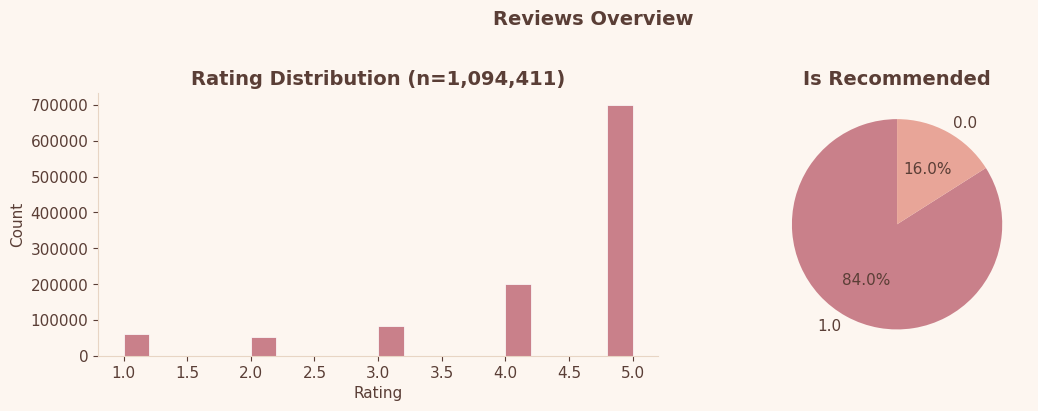

In [5]:
if not reviews.empty:
    # Detect rating column
    rating_col = next((c for c in ['rating', 'stars', 'score', 'review_rating'] if c in reviews.columns), None)
    
    fig, axes = plt.subplots(1, 2 if rating_col else 1, figsize=(12, 4))
    if rating_col is None:
        axes = [axes]
    
    # Rating distribution
    if rating_col:
        ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes
        r = reviews[rating_col].dropna()
        ax.hist(r, bins=20, color=PALETTE[0], edgecolor='white', linewidth=0.5)
        ax.set_title(f'Rating Distribution (n={len(r):,})')
        ax.set_xlabel('Rating')
        ax.set_ylabel('Count')
        print(f'Rating stats:\n{r.describe()}')
    
    # Recommended breakdown
    rec_col = next((c for c in ['is_recommended', 'recommended', 'would_recommend'] if c in reviews.columns), None)
    if rec_col and isinstance(axes, (list, np.ndarray)) and len(axes) > 1:
        ax2 = axes[1]
        counts = reviews[rec_col].value_counts()
        ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                colors=PALETTE[:len(counts)], startangle=90)
        ax2.set_title(f'{rec_col.replace("_", " ").title()}')
    
    plt.suptitle('Reviews Overview', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    savefig('01_reviews_overview')
    plt.show()

  📊 Saved → 01_top_reviewed_products.png


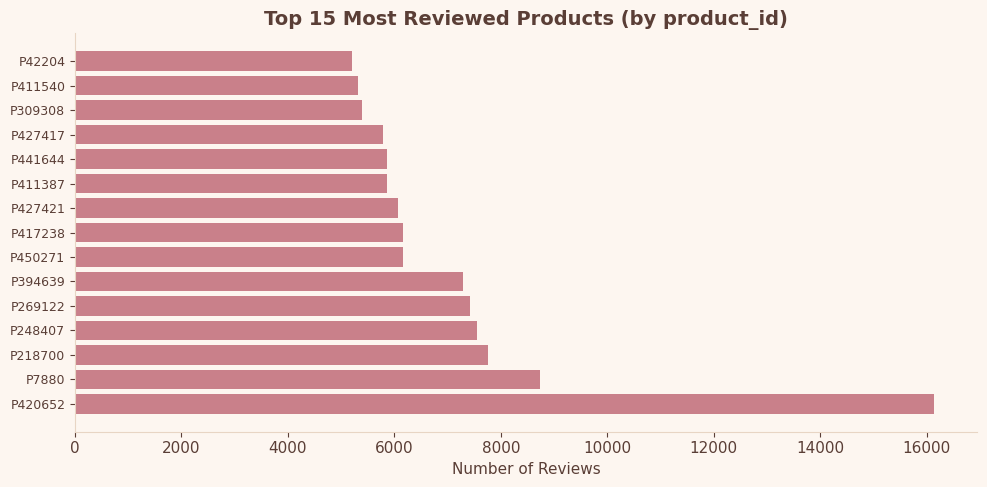

In [6]:
if not reviews.empty:
    # Top reviewers / most reviewed products
    prod_col = next((c for c in ['product_id', 'product_name', 'name', 'sku'] if c in reviews.columns), None)
    
    if prod_col:
        top_products = reviews[prod_col].value_counts().head(15)
        
        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.barh(range(len(top_products)), top_products.values, color=PALETTE[0])
        ax.set_yticks(range(len(top_products)))
        ax.set_yticklabels([str(p)[:40] for p in top_products.index], fontsize=9)
        ax.set_title(f'Top 15 Most Reviewed Products (by {prod_col})')
        ax.set_xlabel('Number of Reviews')
        plt.tight_layout()
        savefig('01_top_reviewed_products')
        plt.show()
    else:
        print(f'Available columns: {list(reviews.columns)}')
        print('⚠️  No product identifier column found — adjust prod_col above')

---
## 3. Skincare Products Analysis

In [7]:
section('SKINCARE PRODUCTS ANALYSIS')

if skincare.empty:
    print('⚠️  Skincare data not available')
else:
    print(f'Shape: {skincare.shape}')
    print(f'\nColumns: {list(skincare.columns)}')
    display(skincare.head(3))


══════════════════════════════════════════════════════════════════════
  SKINCARE PRODUCTS ANALYSIS
══════════════════════════════════════════════════════════════════════
Shape: (3474, 49)

Columns: ['unnamed_0', 'brand', 'name', 'price', 'n_of_reviews', 'n_of_loves', 'review_score', 'size', 'clean_product', 'category_anti_aging', 'category_bb__cc_cream', 'category_bath__shower', 'category_beauty_supplements', 'category_blemish__acne_treatments', 'category_blotting_papers', 'category_body_lotions__body_oils', 'category_cellulite__stretch_marks', 'category_decollete__neck_creams', 'category_exfoliators', 'category_eye_creams__treatments', 'category_eye_masks', 'category_face_masks', 'category_face_oils', 'category_face_primer', 'category_face_serums', 'category_face_sunscreen', 'category_face_wash__cleansers', 'category_facial_peels', 'category_foundation', 'category_hair_oil', 'category_highlighter', 'category_holistic_wellness', 'category_mini_size', 'category_mists__essences', 'cate

,unnamed_0,brand,name,price,n_of_reviews,n_of_loves,review_score,size,clean_product,category_anti_aging,category_bb__cc_cream,category_bath__shower,category_beauty_supplements,category_blemish__acne_treatments,category_blotting_papers,category_body_lotions__body_oils,category_cellulite__stretch_marks,category_decollete__neck_creams,category_exfoliators,category_eye_creams__treatments,category_eye_masks,category_face_masks,category_face_oils,category_face_primer,category_face_serums,category_face_sunscreen,category_face_wash__cleansers,category_facial_peels,category_foundation,category_hair_oil,category_highlighter,category_holistic_wellness,category_mini_size,category_mists__essences,category_moisturizer__treatments,category_moisturizers,category_night_creams,category_setting_spray__powder,category_sheet_masks,category_skincare,category_tinted_moisturizer,category_toners,category_tools,category_value__gift_sets,reviews_to_loves_ratio,return_on_reviews,price_per_ounce,sub_category,category
0,0,Drunk Elephant,Protini Polypeptide Moisturizer,NaN,1000,136008,4.21,NaN,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.74,0.42,40.24,skincare,NaN
1,1,La Mer,Crreme de la Mer,NaN,493,61648,4.10,NaN,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.80,0.83,175.00,skincare,NaN
2,2,IT Cosmetics,CC+ Cream with SPF 50+,NaN,2000,188389,4.04,NaN,0,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.06,0.20,36.11,skincare,NaN



Price stats:
count   1410.00
mean      64.94
std       50.28
min        4.00
25%       37.25
50%       50.00
75%       78.00
max      495.00
Name: price, dtype: float64
  📊 Saved → 02_skincare_overview.png


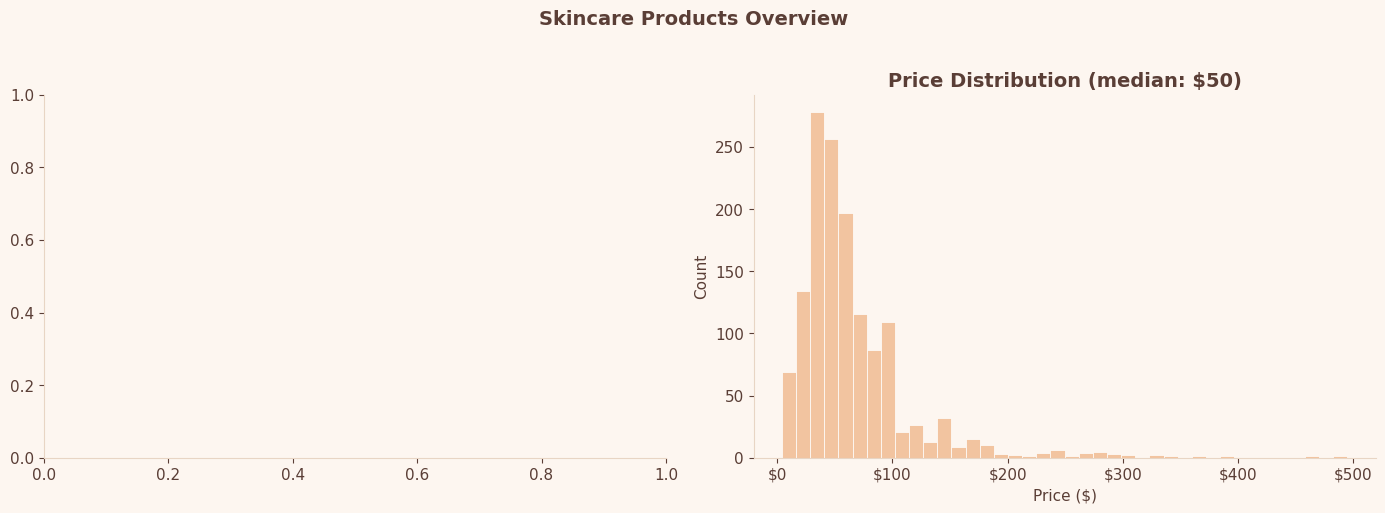

In [8]:
if not skincare.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Category breakdown
    if 'source_category' in skincare.columns:
        cat_counts = skincare['source_category'].value_counts()
        axes[0].pie(cat_counts.values, labels=cat_counts.index,
                    autopct='%1.1f%%', colors=PALETTE[:len(cat_counts)], startangle=90)
        axes[0].set_title('Products by Category')
    
    # Price distribution
    price_col = next((c for c in ['price', 'price_usd', 'cost'] if c in skincare.columns), None)
    if price_col:
        prices = skincare[price_col].dropna()
        prices = prices[prices > 0]
        axes[1].hist(prices, bins=40, color=PALETTE[2], edgecolor='white', linewidth=0.5)
        axes[1].set_title(f'Price Distribution (median: ${prices.median():.0f})')
        axes[1].set_xlabel('Price ($)')
        axes[1].set_ylabel('Count')
        axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
        print(f'\nPrice stats:\n{prices.describe()}')
    
    plt.suptitle('Skincare Products Overview', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    savefig('02_skincare_overview')
    plt.show()

  📊 Saved → 02_top_skincare_brands.png


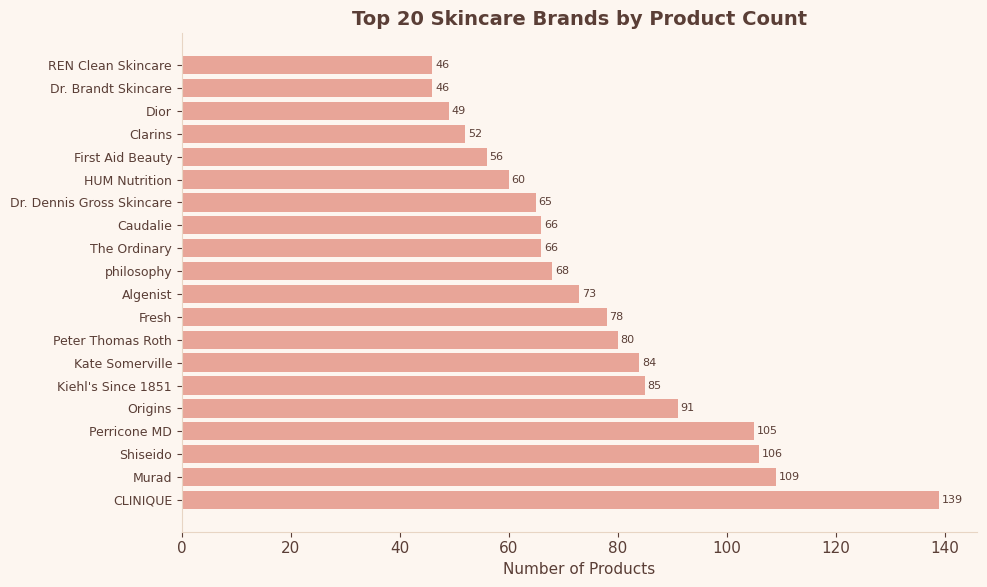

In [9]:
if not skincare.empty:
    # Top brands
    brand_col = next((c for c in ['brand', 'brand_name', 'brand_id'] if c in skincare.columns), None)
    rating_col = next((c for c in ['rating', 'stars', 'score'] if c in skincare.columns), None)
    
    if brand_col:
        top_brands = skincare[brand_col].value_counts().head(20)
        
        fig, ax = plt.subplots(figsize=(10, 6))
        bars = ax.barh(range(len(top_brands)), top_brands.values, color=PALETTE[1])
        ax.set_yticks(range(len(top_brands)))
        ax.set_yticklabels([str(b)[:35] for b in top_brands.index], fontsize=9)
        ax.set_title('Top 20 Skincare Brands by Product Count')
        ax.set_xlabel('Number of Products')
        for bar, val in zip(bars, top_brands.values):
            ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=8)
        plt.tight_layout()
        savefig('02_top_skincare_brands')
        plt.show()
    
    # Rating by category
    if rating_col and 'source_category' in skincare.columns:
        fig, ax = plt.subplots(figsize=(10, 5))
        cat_ratings = skincare.groupby('source_category')[rating_col].mean().sort_values(ascending=False)
        ax.bar(cat_ratings.index, cat_ratings.values, color=PALETTE[:len(cat_ratings)])
        ax.set_title('Average Rating by Product Category')
        ax.set_ylabel('Average Rating')
        ax.set_ylim(0, 5)
        for i, (cat, val) in enumerate(cat_ratings.items()):
            ax.text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=10)
        plt.tight_layout()
        savefig('02_rating_by_category')
        plt.show()

---
## 4. Sephora Catalog Analysis

In [10]:
section('SEPHORA CATALOG ANALYSIS')

if sephora.empty:
    print('⚠️  Sephora data not available')
else:
    print(f'Shape: {sephora.shape}')
    print(f'\nColumns: {list(sephora.columns)}')
    display(sephora.head(3))


══════════════════════════════════════════════════════════════════════
  SEPHORA CATALOG ANALYSIS
══════════════════════════════════════════════════════════════════════
Shape: (2179, 20)

Columns: ['cosmetic_link', 'brand_name', 'cosmetic_name', 'num_customer', 'price', 'ingredients', 'about', 'reviews', 'recommended', 'what_it_is', 'skin_type', 'skincare_concerns', 'formulation', 'benefits', 'highlighted_ingredients', 'ingredient_callouts', 'what_else_you_need_to_know', 'clinical_results', 'clean_ingredients', 'new_ingredients']


,cosmetic_link,brand_name,cosmetic_name,num_customer,price,ingredients,about,reviews,recommended,what_it_is,skin_type,skincare_concerns,formulation,benefits,highlighted_ingredients,ingredient_callouts,what_else_you_need_to_know,clinical_results,clean_ingredients,new_ingredients
0,https://www.sephora.com/product/summer-fridays-lip-butter-balm-P455936?skuId...,Summer Fridays,Lip Butter Balm for Hydration & Shine,6.7K,24.00,"-Shea and Murumuru Seed Butters: Natural moisturizers that soothe, relieve, ...",What it is: A silky vegan balm that hydrates and soothes dry lips in seconds...,4.40,86%,A silky vegan balm that hydrates and soothes dry lips in seconds.,NaN,Dryness and Dullness,NaN,NaN,NaN,"This product is vegan, gluten-free, cruelty-free, and comes in recyclable pa...",This formula delivers soothing moisture to parched lips in seconds. Butter u...,"In an independent clinical study, with 39 participants aged 20 - 55:",NaN,"Phytosteryl/Behenyl Dimer Dilinoleate, Diisostearyl Malate, Hydrogenated Pol..."
1,https://www.sephora.com/product/glow-recipe-watermelon-glow-pha-bha-pore-tig...,Glow Recipe,Watermelon Glow PHA + BHA Pore-Tight Toner,6.1K,NaN,"-Watermelon Extract: Hydrates, soothes, and delivers essential vitamins and ...","What it is: A bestselling, gentle PHA- and BHA-infused watermelon toner that...",4.30,84%,"A bestselling, gentle PHA- and BHA-infused watermelon toner that hydrates, g...","Normal, Dry, Combination, and Oily","Pores, Dryness, and Dullness",Lightweight Liquid,NaN,NaN,"This product is vegan, cruelty-free, and comes in recyclable packaging.","Suitable for all skin types, this bouncy, alcohol-free toner is made with PH...",Based on instrumental testing on 31 women when used as directed After 2 week...,NaN,"Opuntia Ficus-Indica Stem Extract, Citrullus Lanatus (Watermelon) Fruit Extr..."
2,https://www.sephora.com/product/touchland-power-mist-hydrating-hand-sanitize...,Touchland,Power Mist Hydrating Hand Sanitizer,845,10.00,-70% Alcohol: Effective against most common germs.\n-Aloe Vera: Moisturizes ...,"What it is: An award-winning hand sanitizer that does it all: sanitizes, hyd...",4.20,84%,"An award-winning hand sanitizer that does it all: sanitizes, hydrates, and s...",NaN,NaN,NaN,NaN,- 70% Alcohol: Effective against most common germs.\n- Aloe Vera: Moisturize...,NaN,This revolutionary sanitizer has turned hand hygiene into a ritual of skinca...,NaN,NaN,"Alcohol, Deionized/Demineralized Water, Aloe Barbadensis Leaf Juice, Leucono..."


  📊 Saved → 04_sephora_overview.png


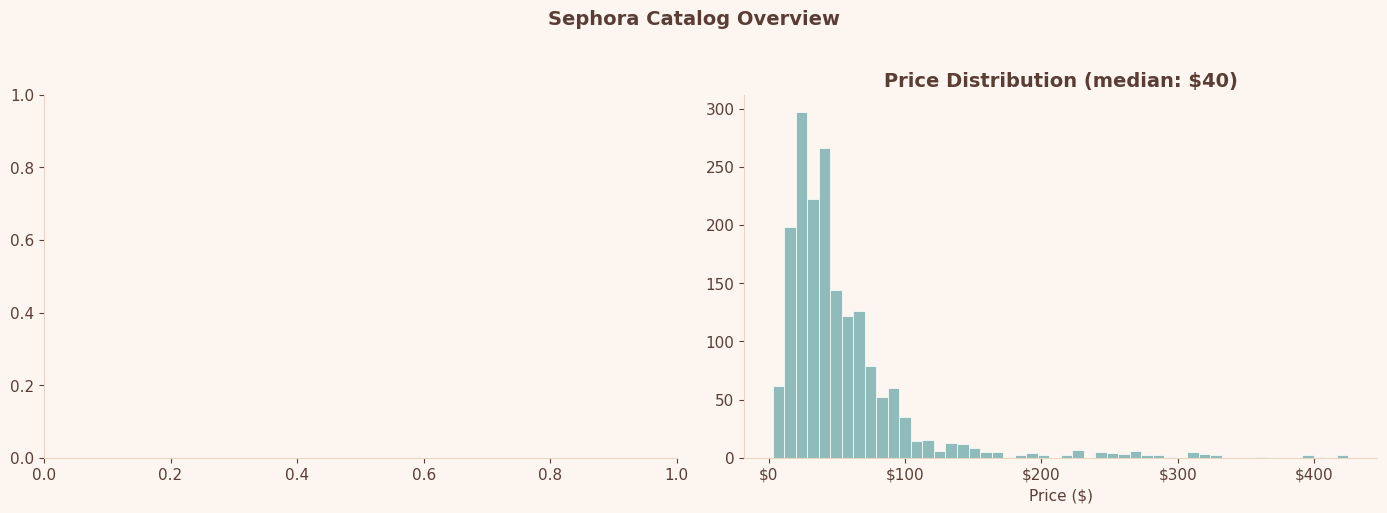

In [11]:
if not sephora.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Category breakdown
    cat_col = next((c for c in ['category', 'primary_category', 'type'] if c in sephora.columns), None)
    if cat_col:
        top_cats = sephora[cat_col].value_counts().head(12)
        axes[0].barh(range(len(top_cats)), top_cats.values, color=PALETTE[3])
        axes[0].set_yticks(range(len(top_cats)))
        axes[0].set_yticklabels([str(c)[:30] for c in top_cats.index], fontsize=9)
        axes[0].set_title('Top Categories')
    
    # Price range
    price_col = next((c for c in ['price', 'price_usd', 'value_price'] if c in sephora.columns), None)
    if price_col:
        prices = pd.to_numeric(sephora[price_col], errors='coerce').dropna()
        prices = prices[(prices > 0) & (prices < 1000)]
        axes[1].hist(prices, bins=50, color=PALETTE[4], edgecolor='white', linewidth=0.5)
        axes[1].set_title(f'Price Distribution (median: ${prices.median():.0f})')
        axes[1].set_xlabel('Price ($)')
        axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
    
    plt.suptitle('Sephora Catalog Overview', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    savefig('04_sephora_overview')
    plt.show()

---
## 5. Makeup Analysis

In [12]:
section('MAKEUP ANALYSIS')

if makeup.empty:
    print('⚠️  Makeup data not available')
else:
    print(f'Shape: {makeup.shape}')
    print(f'\nColumns: {list(makeup.columns)}')
    display(makeup.head(3))


══════════════════════════════════════════════════════════════════════
  MAKEUP ANALYSIS
══════════════════════════════════════════════════════════════════════
Shape: (931, 19)

Columns: ['id', 'brand', 'name', 'price', 'price_sign', 'currency', 'image_link', 'product_link', 'website_link', 'description', 'rating', 'category', 'product_type', 'tag_list', 'created_at', 'updated_at', 'product_api_url', 'api_featured_image', 'product_colors']


,id,brand,name,price,price_sign,currency,image_link,product_link,website_link,description,rating,category,product_type,tag_list,created_at,updated_at,product_api_url,api_featured_image,product_colors
0,1048,colourpop,Lippie Pencil,5.00,NaN,CAD,https://cdn.shopify.com/s/files/1/1338/0845/collections/lippie-pencil_grande...,https://colourpop.com/collections/lippie-pencil,https://colourpop.com,Lippie Pencil A long-wearing and high-intensity lip pencil that glides on ea...,NaN,pencil,lip_liner,NaN,2018-07-08T23:45:08.056Z,2018-07-09T00:53:23.301Z,http://makeup-api.herokuapp.com/api/v1/products/1048.json,//s3.amazonaws.com/donovanbailey/products/api_featured_images/000/001/048/or...,NaN
1,1047,colourpop,Blotted Lip,5.50,NaN,CAD,https://cdn.shopify.com/s/files/1/1338/0845/products/brain-freeze_a_800x1200...,https://colourpop.com/collections/lippie-stix?filter=blotted-lip,https://colourpop.com,Blotted Lip Sheer matte lipstick that creates the perfect popsicle pout! For...,NaN,lipstick,lipstick,NaN,2018-07-08T22:01:20.178Z,2018-07-09T00:53:23.287Z,http://makeup-api.herokuapp.com/api/v1/products/1047.json,//s3.amazonaws.com/donovanbailey/products/api_featured_images/000/001/047/or...,NaN
2,1046,colourpop,Lippie Stix,5.50,NaN,CAD,https://cdn.shopify.com/s/files/1/1338/0845/collections/blottedlip-lippie-st...,https://colourpop.com/collections/lippie-stix,https://colourpop.com,"Lippie Stix Formula contains Vitamin E, Mango, Avocado, and Shea butter for ...",NaN,lipstick,lipstick,NaN,2018-07-08T21:47:49.858Z,2018-07-09T00:53:23.274Z,http://makeup-api.herokuapp.com/api/v1/products/1046.json,//s3.amazonaws.com/donovanbailey/products/api_featured_images/000/001/046/or...,NaN


  📊 Saved → 05_makeup_overview.png


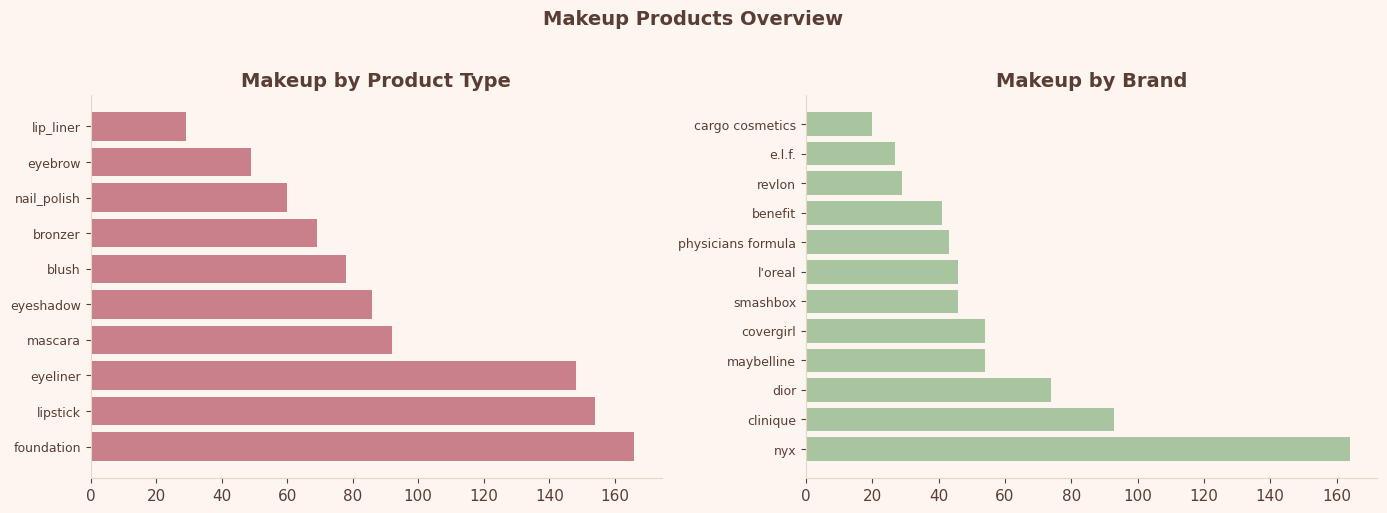

In [13]:
if not makeup.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Product type breakdown
    type_col = next((c for c in ['product_type', 'type', 'category', 'tag'] if c in makeup.columns), None)
    if type_col:
        type_counts = makeup[type_col].value_counts().head(12)
        axes[0].barh(range(len(type_counts)), type_counts.values, color=PALETTE[0])
        axes[0].set_yticks(range(len(type_counts)))
        axes[0].set_yticklabels([str(t)[:30] for t in type_counts.index], fontsize=9)
        axes[0].set_title('Makeup by Product Type')
    
    # Brand distribution
    brand_col = next((c for c in ['brand', 'brand_name'] if c in makeup.columns), None)
    if brand_col:
        brand_counts = makeup[brand_col].value_counts().head(12)
        axes[1].barh(range(len(brand_counts)), brand_counts.values, color=PALETTE[5])
        axes[1].set_yticks(range(len(brand_counts)))
        axes[1].set_yticklabels([str(b)[:30] for b in brand_counts.index], fontsize=9)
        axes[1].set_title('Makeup by Brand')
    
    plt.suptitle('Makeup Products Overview', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    savefig('05_makeup_overview')
    plt.show()

---
## 6. Popularity & Rankings

In [14]:
section('POPULARITY & RANKINGS ANALYSIS')

if rankings.empty:
    print('⚠️  Rankings data not available')
else:
    print(f'Shape: {rankings.shape}')
    print(f'\nColumns: {list(rankings.columns)}')
    display(rankings.head(5))


══════════════════════════════════════════════════════════════════════
  POPULARITY & RANKINGS ANALYSIS
══════════════════════════════════════════════════════════════════════
Shape: (400, 8)

Columns: ['unnamed_0', 'brand', 'name', 'price', 'ranking_type', 'sumn_of_loves', 'sumn_of_reviews', 'sumreview_score']


,unnamed_0,brand,name,price,ranking_type,sumn_of_loves,sumn_of_reviews,sumreview_score
0,0,Perricone MD,Neuropeptide Smoothing Facial Conformer,495.00,most_expensive,NaN,NaN,NaN
1,1,Guerlain,Orchid√©e Imp√©riale The Cream,460.00,most_expensive,NaN,NaN,NaN
2,2,SK-II,Ultimate Revival Cream,385.00,most_expensive,NaN,NaN,NaN
3,3,La Mer,The Concentrate,370.00,most_expensive,NaN,NaN,NaN
4,4,La Mer,The Regenerating Serum,345.00,most_expensive,NaN,NaN,NaN


  📊 Saved → 06_rankings_overview.png


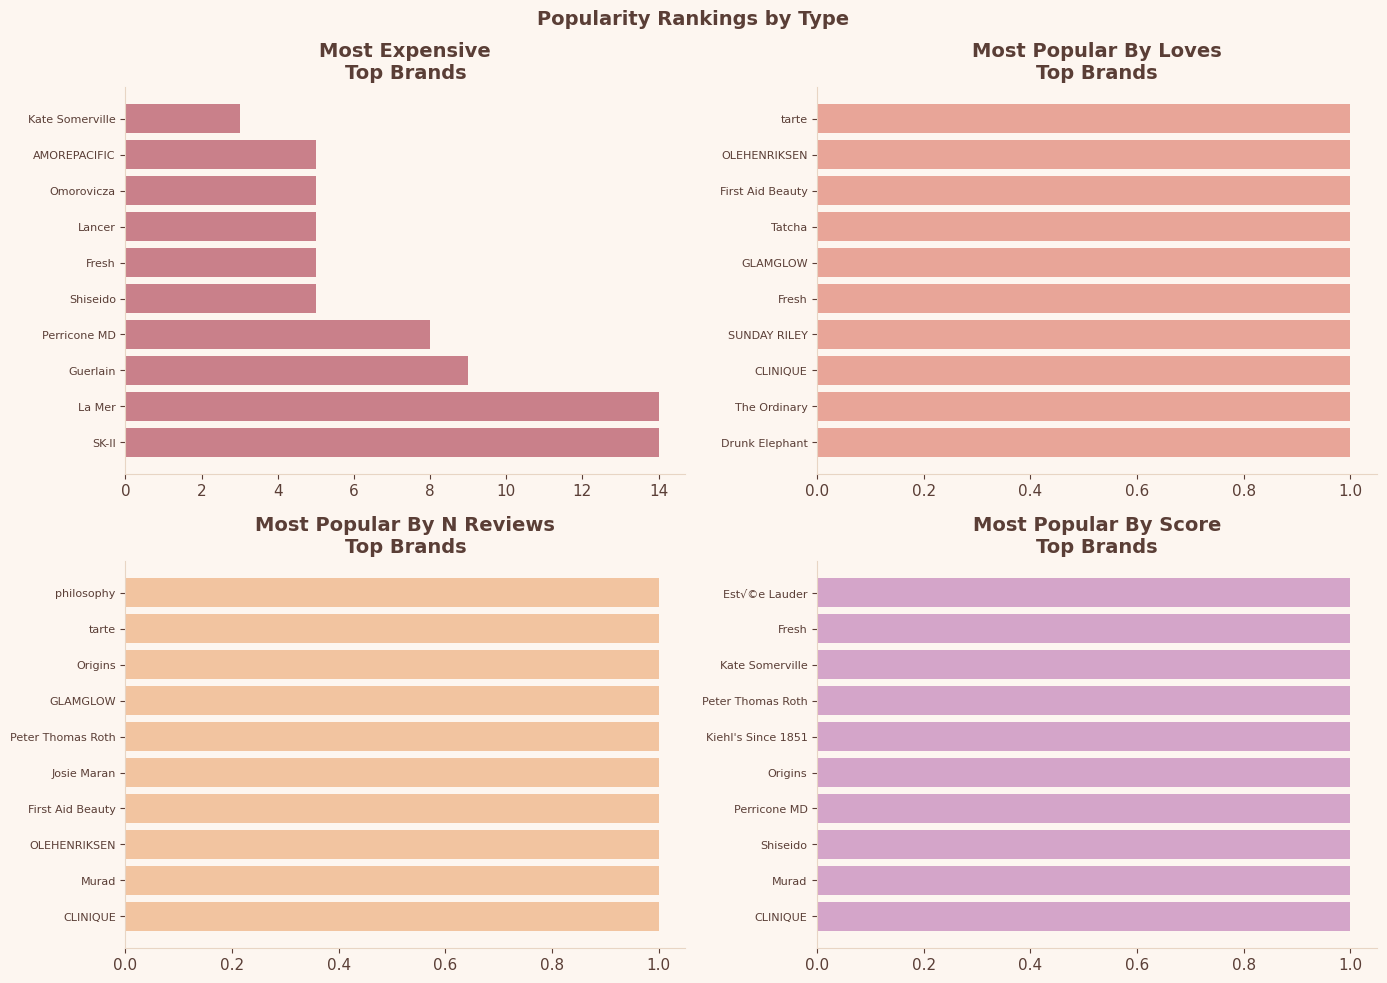

In [15]:
if not rankings.empty:
    if 'ranking_type' in rankings.columns:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.flatten()
        
        for idx, rtype in enumerate(rankings['ranking_type'].unique()[:4]):
            subset = rankings[rankings['ranking_type'] == rtype]
            
            brand_col = next((c for c in ['brand', 'brand_name'] if c in subset.columns), None)
            name_col = next((c for c in ['name', 'product_name', 'product_id'] if c in subset.columns), None)
            
            if brand_col:
                top = subset[brand_col].value_counts().head(10)
                axes[idx].barh(range(len(top)), top.values, color=PALETTE[idx])
                axes[idx].set_yticks(range(len(top)))
                axes[idx].set_yticklabels([str(b)[:30] for b in top.index], fontsize=8)
                axes[idx].set_title(f'{rtype.replace("_", " ").title()}\nTop Brands')
        
        plt.suptitle('Popularity Rankings by Type', fontsize=14, fontweight='bold')
        plt.tight_layout()
        savefig('06_rankings_overview')
        plt.show()

---
## 7. Ingredients Analysis

In [16]:
section('INGREDIENTS ANALYSIS')

if ingredients.empty:
    print('⚠️  Ingredients data not available')
else:
    print(f'Shape: {ingredients.shape}')
    print(f'\nColumns: {list(ingredients.columns)}')
    display(ingredients.head(3))


══════════════════════════════════════════════════════════════════════
  INGREDIENTS ANALYSIS
══════════════════════════════════════════════════════════════════════
Shape: (66417, 2)

Columns: ['cosmetic', 'ingredient']


,cosmetic,ingredient
0,Lip Butter Balm for Hydration & Shine,Phytosteryl/Behenyl Dimer Dilinoleate
1,Lip Butter Balm for Hydration & Shine,Diisostearyl Malate
2,Lip Butter Balm for Hydration & Shine,Hydrogenated Polyisobutene


In [17]:
if not ingredients.empty:
    # Binary ingredient columns (0/1 flags)
    bool_cols = [c for c in ingredients.columns
                 if ingredients[c].dropna().isin([0, 1]).all() and c not in ['unnamed_0']]
    
    if bool_cols:
        # Top most common ingredients
        ingredient_prevalence = ingredients[bool_cols].sum().sort_values(ascending=False)
        top_ingredients = ingredient_prevalence.head(20)
        
        fig, ax = plt.subplots(figsize=(10, 7))
        bars = ax.barh(range(len(top_ingredients)), top_ingredients.values, color=PALETTE[6])
        ax.set_yticks(range(len(top_ingredients)))
        ax.set_yticklabels([c.replace('_', ' ').title()[:35] for c in top_ingredients.index], fontsize=9)
        ax.set_title(f'Top 20 Most Common Ingredients\n(out of {len(bool_cols)} total ingredients)')
        ax.set_xlabel('Number of Products Containing Ingredient')
        for bar, val in zip(bars, top_ingredients.values):
            ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val):,}', va='center', fontsize=8)
        plt.tight_layout()
        savefig('07_top_ingredients')
        plt.show()
        
        print(f'\nTotal unique ingredients tracked: {len(bool_cols)}')
        print(f'Products in dataset: {len(ingredients):,}')
    else:
        print(f'No binary ingredient columns found.')
        print(f'Columns: {list(ingredients.columns)}')

No binary ingredient columns found.
Columns: ['cosmetic', 'ingredient']


---
## 8. Missing Values Heatmap


══════════════════════════════════════════════════════════════════════
  MISSING VALUES DEEP DIVE
══════════════════════════════════════════════════════════════════════
  📊 Saved → 08_missing_values.png


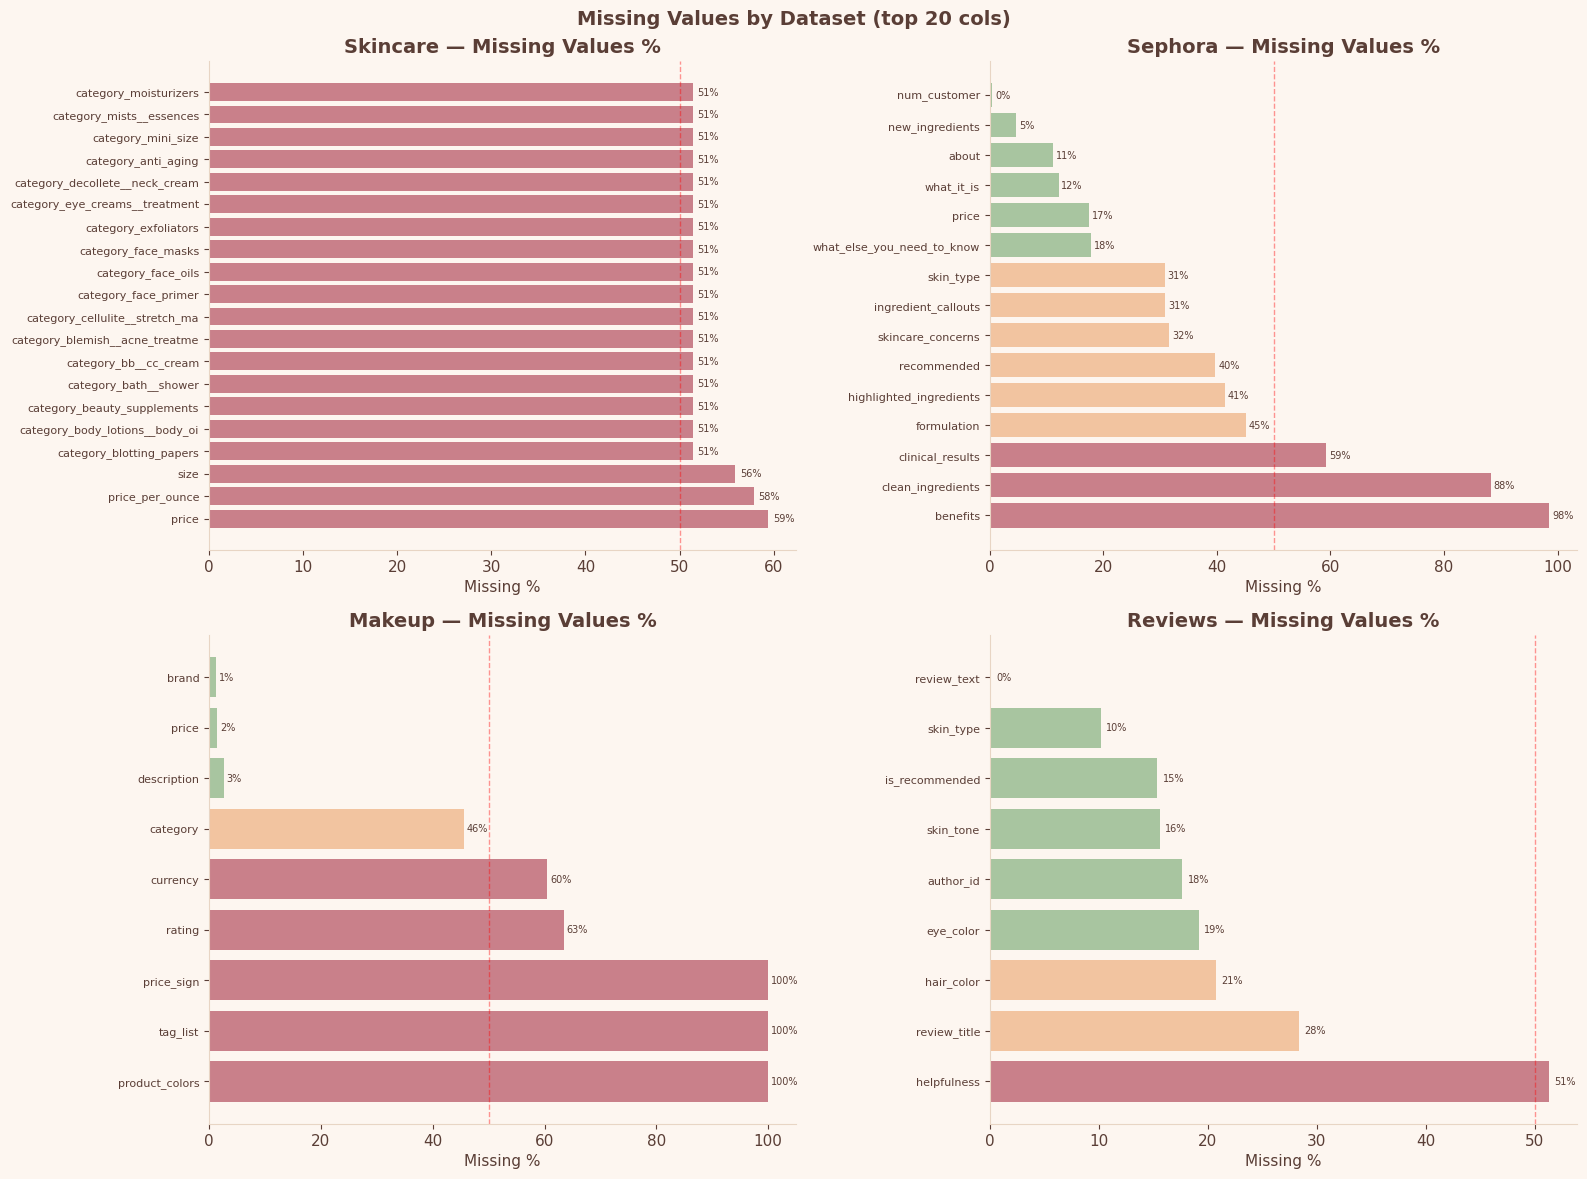

In [18]:
section('MISSING VALUES DEEP DIVE')

# Focus on the most important datasets for recommendation engine
key_datasets = {
    'Skincare': skincare,
    'Sephora': sephora,
    'Makeup': makeup,
    'Reviews': reviews,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, df) in enumerate(key_datasets.items()):
    ax = axes[idx]
    if df.empty:
        ax.text(0.5, 0.5, f'{name}\nnot available', ha='center', va='center', transform=ax.transAxes)
        continue
    
    missing = (df.isnull().mean() * 100).sort_values(ascending=False)
    missing = missing[missing > 0].head(20)
    
    if missing.empty:
        ax.text(0.5, 0.5, f'{name}\nNo missing values! ✓', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='green')
    else:
        colors = ['#c9808a' if v > 50 else '#f2c4a0' if v > 20 else '#a8c5a0' for v in missing.values]
        ax.barh(range(len(missing)), missing.values, color=colors)
        ax.set_yticks(range(len(missing)))
        ax.set_yticklabels([c[:30] for c in missing.index], fontsize=8)
        ax.set_title(f'{name} — Missing Values %')
        ax.set_xlabel('Missing %')
        ax.axvline(50, color='red', linestyle='--', alpha=0.4, linewidth=1)
        for bar, val in zip(ax.patches, missing.values):
            ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=7)

plt.suptitle('Missing Values by Dataset (top 20 cols)', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('08_missing_values')
plt.show()

---
## 9. Key Insights Summary

In [19]:
section('KEY INSIGHTS SUMMARY')

insights = []

if not reviews.empty:
    rating_col = next((c for c in ['rating', 'stars', 'score'] if c in reviews.columns), None)
    if rating_col:
        avg_rating = reviews[rating_col].mean()
        insights.append(f'⭐ Average review rating: {avg_rating:.2f}')
    insights.append(f'📝 Total reviews: {len(reviews):,}')

if not skincare.empty:
    insights.append(f'🧴 Total skincare products: {len(skincare):,}')
    price_col = next((c for c in ['price', 'price_usd'] if c in skincare.columns), None)
    if price_col:
        med_price = pd.to_numeric(skincare[price_col], errors='coerce').median()
        insights.append(f'💰 Median skincare price: ${med_price:.0f}')

if not sephora.empty:
    insights.append(f'🏬 Sephora catalog size: {len(sephora):,} products')

if not makeup.empty:
    insights.append(f'💄 Makeup products: {len(makeup):,}')

if not ingredients.empty:
    bool_cols = [c for c in ingredients.columns if ingredients[c].dropna().isin([0, 1]).all()]
    insights.append(f'🧪 Unique ingredients tracked: {len(bool_cols):,}')

print('\n🔍 KEY INSIGHTS FOR PUREGLOW AI:\n')
for insight in insights:
    print(f'  {insight}')

# Columns critical for recommendation engine
print('\n\n📋 COLUMNS NEEDED FOR RECOMMENDATION ENGINE:')
print('\n  Skincare products dataset should have:')
for needed in ['brand', 'name', 'price', 'rating', 'skin_type', 'ingredients', 'category']:
    have = any(needed in c for c in skincare.columns) if not skincare.empty else False
    status = '✓' if have else '✗ MISSING'
    print(f'    {status}  {needed}')

print('\n  Reviews dataset should have:')
for needed in ['product_id', 'rating', 'review_text', 'author_id']:
    have = any(needed in c for c in reviews.columns) if not reviews.empty else False
    status = '✓' if have else '✗ MISSING'
    print(f'    {status}  {needed}')


══════════════════════════════════════════════════════════════════════
  KEY INSIGHTS SUMMARY
══════════════════════════════════════════════════════════════════════

🔍 KEY INSIGHTS FOR PUREGLOW AI:

  ⭐ Average review rating: 4.30
  📝 Total reviews: 1,094,411
  🧴 Total skincare products: 3,474
  💰 Median skincare price: $50
  🏬 Sephora catalog size: 2,179 products
  💄 Makeup products: 931
  🧪 Unique ingredients tracked: 0


📋 COLUMNS NEEDED FOR RECOMMENDATION ENGINE:

  Skincare products dataset should have:
    ✓  brand
    ✓  name
    ✓  price
    ✗ MISSING  rating
    ✗ MISSING  skin_type
    ✗ MISSING  ingredients
    ✓  category

  Reviews dataset should have:
    ✓  product_id
    ✓  rating
    ✓  review_text
    ✓  author_id


In [20]:
# Export summary report
print('\n📊 Generating summary report...\n')

summary = {}
for name, df in datasets.items():
    if not df.empty:
        summary[name] = {
            'rows': len(df),
            'columns': list(df.columns),
            'missing_pct': round(df.isnull().mean().mean() * 100, 2)
        }

import json
report_path = REPORTS_DIR / 'eda_summary.json'
with open(report_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f'✅ EDA complete!')
print(f'📁 Charts saved to  : {REPORTS_DIR}')
print(f'📄 JSON summary     : {report_path}')
print(f'\n📌 Next step → 03_build_master_product_db.ipynb')


📊 Generating summary report...

✅ EDA complete!
📁 Charts saved to  : C:\Users\HP\OneDrive\Desktop\PureGlow AI\reports
📄 JSON summary     : C:\Users\HP\OneDrive\Desktop\PureGlow AI\reports\eda_summary.json

📌 Next step → 03_build_master_product_db.ipynb
